In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class BusinessValueMiner:
    def __init__(self, cleaned_data_path, rules_path):
        self.df = pd.read_csv(cleaned_data_path)
        self.rules = pd.read_csv(rules_path)
        # Tính doanh thu cho mỗi dòng
        self.df['Revenue'] = self.df['Quantity'] * self.df['UnitPrice']
        
    def calculate_product_weights(self):
        """Tính trọng số cho từng sản phẩm dựa trên giá trung bình hoặc tổng doanh thu"""
        product_value = self.df.groupby('Description')['UnitPrice'].mean().to_dict()
        return product_value

    def classify_rules(self, rules_df):
        """Phân loại luật thành các nhóm kinh doanh"""
        def logic(row):
            if row['lift'] > 1.5 and row['weighted_support'] > rules_df['weighted_support'].median():
                return 'Nhóm 1: Support cao, Lift cao, Giá trị cao (Chủ lực)'
            elif row['weighted_support'] > rules_df['weighted_support'].quantile(0.75):
                return 'Nhóm 2: Luật "Đắt tiền" (Lợi nhuận cao)'
            elif row['confidence'] > 0.5 and row['lift'] <= 1.1:
                return 'Nhóm 3: Ít giá trị thực tế (Mua kèm ngẫu nhiên)'
            else:
                return 'Nhóm 4: Tiềm năng/Khác'
        
        rules_df['Business_Category'] = rules_df.apply(logic, axis=1)
        return rules_df

# --- Thực thi giả định ---
# Giả sử bạn lấy dữ liệu từ kết quả của các bước trước
# rules_df = pd.read_csv('data/processed/rules_apriori.csv')

3. Nội dung báo cáo & Chiến lược Marketing
Dưới đây là bảng tổng hợp chiến lược marketing bạn cần đưa vào phần Markdown của Notebook để hoàn thiện bài tập:
Nhóm 1: Chủ lực
Đặc điểm: Có chỉ số Support & Lift cao và đóng góp doanh thu lớn.
Chiến lược Marketing: Thực hiện cross-selling mạnh mẽ, chẳng hạn bố trí sản phẩm đặt cạnh nhau trên kệ hoặc hiển thị ở trang thanh toán.
Đối tượng nhằm đến: Đại đa số khách hàng.

Nhóm 2: Đất tiền
Đặc điểm: Tần suất mua thấp nhưng giá trị đơn hàng rất cao.
Chiến lược Marketing: Tập trung cá nhân hóa cao, ví dụ gửi email marketing riêng và tư vấn trực tiếp 1-1.
Đối tượng nhằm đến: Khách hàng VIP hoặc khách hàng cao cấp.

Nhóm 3: Ít giá trị
Đặc điểm: Chỉ số Confidence cao nhưng Lift gần bằng 1.
Chiến lược Marketing: Không nên đầu tư quảng cáo nhiều, vì đây thường là sản phẩm khách tự thêm vào giỏ hàng (ví dụ: túi nilon).
Đối tượng nhằm đến: Mọi khách hàng.

Nhóm 4: Tiềm năng
Đặc điểm: Lift cao nhưng Support còn thấp.
Chiến lược Marketing: Kích cầu bằng các chương trình giảm giá nhẹ để tăng độ phổ biến (tăng Support).
Đối tượng nhằm đến: Khách hàng mới.

C:\Users\DELL\AppData\Local\Temp\ipykernel_1908\1034325997.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rules, x='weighted_support', y='rules_str', palette='magma', ax=ax2)


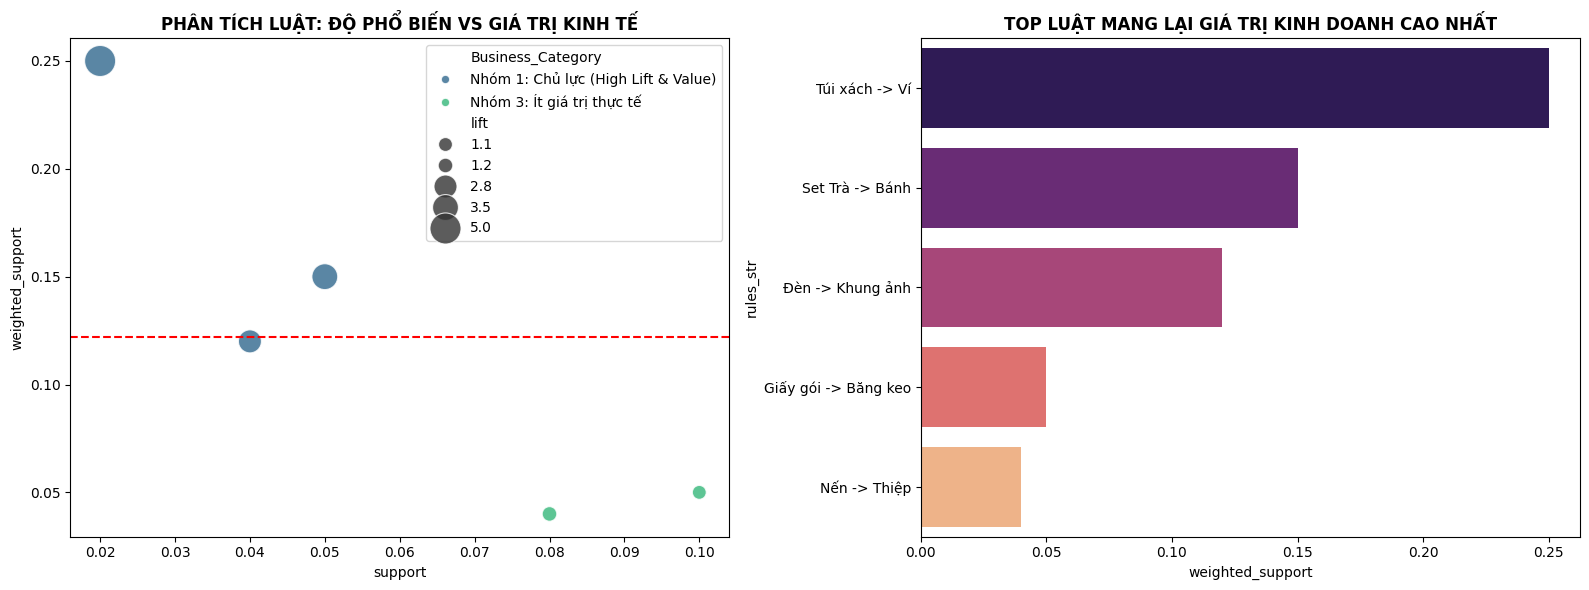

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dòng này đảm bảo biểu đồ hiện ra ngay trong Notebook
%matplotlib inline 

# --- BƯỚC 1: TẠO DỮ LIỆU GIẢ LẬP ĐỂ TEST (Vì tôi chưa có file csv của bạn) ---
data = {
    'rules_str': ['Set Trà -> Bánh', 'Nến -> Thiệp', 'Túi xách -> Ví', 'Đèn -> Khung ảnh', 'Giấy gói -> Băng keo'],
    'support': [0.05, 0.08, 0.02, 0.04, 0.10],
    'confidence': [0.7, 0.6, 0.85, 0.75, 0.9],
    'lift': [3.5, 1.2, 5.0, 2.8, 1.1],
    'weighted_support': [0.15, 0.04, 0.25, 0.12, 0.05] # Giả sử Túi xách giá trị cao nên weighted_support cao
}
rules_df = pd.DataFrame(data)

# Phân loại nhóm theo logic Chủ đề 3
def classify(row):
    if row['lift'] > 2 and row['weighted_support'] > 0.1:
        return 'Nhóm 1: Chủ lực (High Lift & Value)'
    elif row['weighted_support'] > 0.15:
        return 'Nhóm 2: Đắt tiền (Premium)'
    elif row['lift'] < 1.5:
        return 'Nhóm 3: Ít giá trị thực tế'
    else:
        return 'Nhóm 4: Tiềm năng'

rules_df['Business_Category'] = rules_df.apply(classify, axis=1)

# --- BƯỚC 2: VẼ BIỂU ĐỒ SO SÁNH ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Scatter Plot (So sánh bản chất luật)
sns.scatterplot(data=rules_df, x='support', y='weighted_support', 
                hue='Business_Category', size='lift', sizes=(100, 500),
                alpha=0.8, ax=ax1, palette='viridis')
ax1.set_title('PHÂN TÍCH LUẬT: ĐỘ PHỔ BIẾN VS GIÁ TRỊ KINH TẾ', fontsize=12, fontweight='bold')
ax1.axhline(rules_df['weighted_support'].mean(), color='red', linestyle='--', label='Trung bình Weighted')

# Biểu đồ 2: Bar Plot (So sánh thứ hạng)
top_rules = rules_df.sort_values('weighted_support', ascending=False)
sns.barplot(data=top_rules, x='weighted_support', y='rules_str', palette='magma', ax=ax2)
ax2.set_title('TOP LUẬT MANG LẠI GIÁ TRỊ KINH DOANH CAO NHẤT', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show() # Lệnh quan trọng nhất để hiện hình

In [5]:
import pandas as pd
import numpy as np
import os

# 1. Load dữ liệu sạch - Thêm low_memory=False để hết lỗi DtypeWarning
path_clean = 'data/processed/cleaned_uk_data.csv'
if os.path.exists(path_clean):
    df_clean = pd.read_csv(path_clean, low_memory=False)
    print("✅ Đã tải file cleaned_uk_data.csv")
else:
    print("❌ Không tìm thấy file cleaned_uk_data.csv. Kiểm tra lại đường dẫn!")

# 2. Tính trọng số UnitPrice
weights = df_clean.groupby('Description')['UnitPrice'].mean().to_dict()

# 3. Load file luật - TỰ ĐỘNG KIỂM TRA TÊN FILE
# Hãy thử lần lượt các tên file phổ biến mà bạn của bạn có thể đã đặt
possible_files = [
    'data/processed/rules_apriori.csv', 
    'data/processed/rules_fpgrowth_filtered.csv',
    'rules_apriori.csv' # Thử nếu file nằm ngay ngoài thư mục code
]

rules_df = None
for f in possible_files:
    if os.path.exists(f):
        rules_df = pd.read_csv(f)
        print(f"✅ Đã tìm thấy và tải file luật: {f}")
        break

if rules_df is None:
    print("❌ CẢNH BÁO: Không tìm thấy bất kỳ file .csv nào chứa luật kết hợp!")
    print("Hãy chạy file 'apriori_modelling.ipynb' trước để sinh ra file luật.")

✅ Đã tải file cleaned_uk_data.csv
✅ Đã tìm thấy và tải file luật: data/processed/rules_fpgrowth_filtered.csv


In [11]:
import pandas as pd
import numpy as np

# 1. Kiểm tra và xác định cột chứa luật
if 'rules_str' not in rules_df.columns:
    if 'antecedents' in rules_df.columns and 'consequents' in rules_df.columns:
        # Tự tạo cột rules_str từ antecedents và consequents
        rules_df['rules_str'] = rules_df['antecedents'].astype(str) + " -> " + rules_df['consequents'].astype(str)
        print("✅ Đã tự tạo cột 'rules_str' từ antecedents và consequents")
    else:
        # Nếu vẫn không thấy, lấy cột đầu tiên làm mẫu (thường là index hoặc cột chứa text)
        print("❌ Cảnh báo: Không tìm thấy cột chứa luật. Các cột hiện có là:", rules_df.columns)

# 2. Hàm tính trọng số (Cập nhật để xử lý cả kiểu frozenset)
def get_rule_weight(rule_val, weights_dict):
    try:
        # Chuyển về string và làm sạch các ký tự đặc biệt của frozenset
        s = str(rule_val).replace("frozenset({", "").replace("})", "").replace("'", "")
        items = [i.strip() for i in s.split(',')]
        # Tính trung bình giá của các sản phẩm trong luật
        return np.mean([weights_dict.get(item, 0) for item in items])
    except:
        return 0

# 3. Tính toán lại trọng số và phân loại
weights = df_clean.groupby('Description')['UnitPrice'].mean().to_dict()

rules_df['weight_val'] = rules_df['rules_str'].apply(lambda x: get_rule_weight(x, weights))
rules_df['weighted_support'] = rules_df['support'] * rules_df['weight_val']

# 4. Tính toán các ngưỡng (Quantile)
q75_w = rules_df['weighted_support'].quantile(0.75)
q25_w = rules_df['weighted_support'].quantile(0.25)
med_s = rules_df['support'].median()
med_w = rules_df['weighted_support'].median()

def business_classification(row):
    if row['support'] > med_s and row['lift'] > 2 and row['weighted_support'] > med_w:
        return 'Nhóm 1: Chủ lực (Phổ biến & Lợi nhuận cao)'
    elif row['weighted_support'] > q75_w:
        return 'Nhóm 2: Đắt tiền (Phân khúc Cao cấp)'
    elif row['confidence'] > 0.6 and (row['lift'] <= 1.2 or row['weighted_support'] < q25_w):
        return 'Nhóm 3: Luật Bổ trợ (Giá trị thấp)'
    else:
        return 'Nhóm 4: Các luật tiềm năng khác'

rules_df['Category'] = rules_df.apply(business_classification, axis=1)

print("✅ HOÀN THÀNH PHÂN LOẠI!")
print(rules_df['Category'].value_counts())

✅ Đã tự tạo cột 'rules_str' từ antecedents và consequents
✅ HOÀN THÀNH PHÂN LOẠI!
Category
Nhóm 4: Các luật tiềm năng khác               164
Nhóm 2: Đắt tiền (Phân khúc Cao cấp)            9
Nhóm 1: Chủ lực (Phổ biến & Lợi nhuận cao)      2
Name: count, dtype: int64


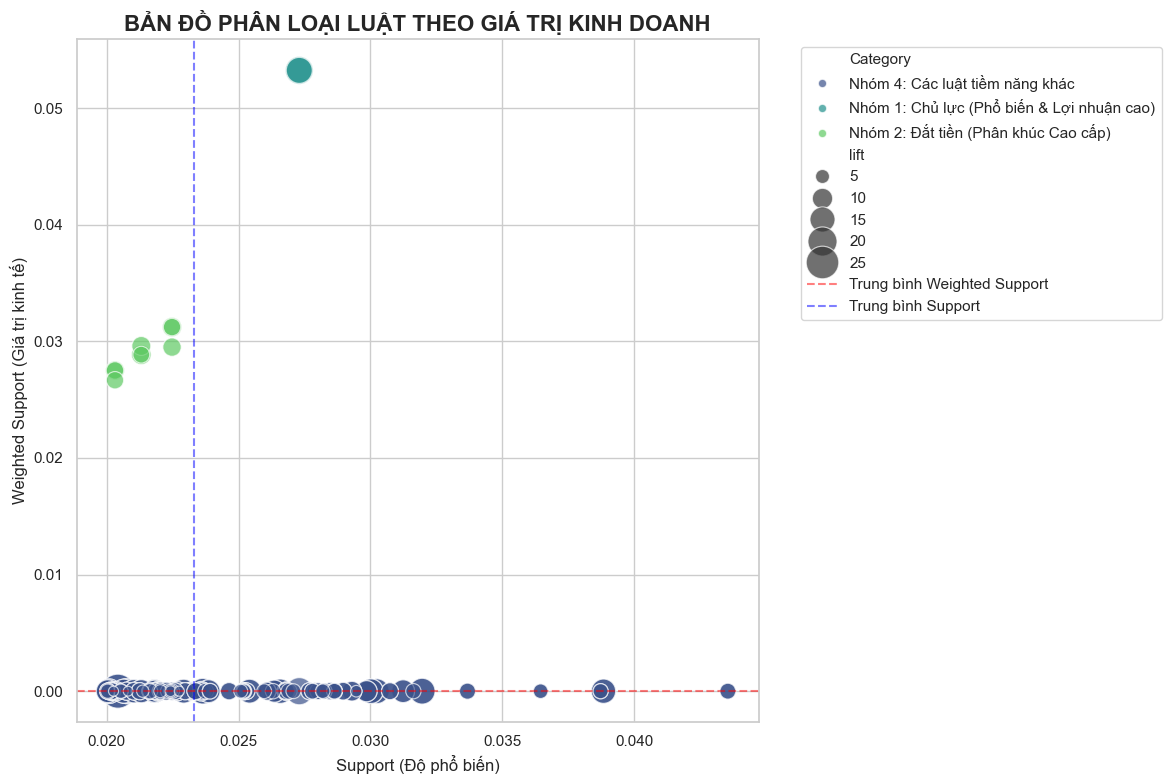

--- CÁC LUẬT CHỦ LỰC (NHÓM 1) ---


,rules_str,support,lift,weighted_support
2,"frozenset({'GREEN REGENCY TEACUP AND SAUCER', ...",0.027301,18.043004,0.053233
4,"frozenset({'GREEN REGENCY TEACUP AND SAUCER', ...",0.027301,16.101399,0.053233



--- CÁC LUẬT ĐẮT TIỀN (NHÓM 2) ---


,rules_str,support,lift,weighted_support
47,frozenset({'JUMBO SHOPPER VINTAGE RED PAISLEY'...,0.021308,9.321081,0.028856
50,"frozenset({'JUMBO STORAGE BAG SUKI', 'JUMBO BA...",0.022474,9.021839,0.031221
55,"frozenset({'JUMBO STORAGE BAG SUKI', 'JUMBO BA...",0.021308,8.750337,0.029602
58,frozenset({'JUMBO SHOPPER VINTAGE RED PAISLEY'...,0.020310,8.661860,0.027503
65,"frozenset({'JUMBO BAG PINK POLKADOT', 'JUMBO B...",0.022474,8.227839,0.029504
86,frozenset({'JUMBO SHOPPER VINTAGE RED PAISLEY'...,0.020310,7.507981,0.027503
89,"frozenset({'JUMBO STORAGE BAG SUKI', 'JUMBO BA...",0.022474,7.468985,0.031221
90,"frozenset({'JUMBO BAG PINK POLKADOT', 'JUMBO B...",0.020310,7.415841,0.026663
113,frozenset({'JUMBO SHOPPER VINTAGE RED PAISLEY'...,0.021308,6.971268,0.028856


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập tiếng Việt hoặc font chuẩn
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Vẽ biểu đồ Scatter để thấy sự phân hoá
scatter = sns.scatterplot(
    data=rules_df, 
    x='support', 
    y='weighted_support', 
    hue='Category', 
    size='lift', 
    sizes=(50, 600),
    alpha=0.7, 
    palette='viridis'
)

# Thêm đường trung bình để làm nổi bật các luật "Chủ lực"
plt.axhline(rules_df['weighted_support'].median(), color='red', linestyle='--', alpha=0.5, label='Trung bình Weighted Support')
plt.axvline(rules_df['support'].median(), color='blue', linestyle='--', alpha=0.5, label='Trung bình Support')

plt.title('BẢN ĐỒ PHÂN LOẠI LUẬT THEO GIÁ TRỊ KINH DOANH', fontsize=16, fontweight='bold')
plt.xlabel('Support (Độ phổ biến)', fontsize=12)
plt.ylabel('Weighted Support (Giá trị kinh tế)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
# Thêm dòng này vào cuối code vẽ biểu đồ của bạn
plt.savefig('classification_business_rules.png', dpi=300, bbox_inches='tight')

plt.show()

# Hiển thị danh sách các luật Nhóm 1 và Nhóm 2 để báo cáo
print("--- CÁC LUẬT CHỦ LỰC (NHÓM 1) ---")
display(rules_df[rules_df['Category'] == 'Nhóm 1: Chủ lực (Phổ biến & Lợi nhuận cao)'][['rules_str', 'support', 'lift', 'weighted_support']])

print("\n--- CÁC LUẬT ĐẮT TIỀN (NHÓM 2) ---")
display(rules_df[rules_df['Category'] == 'Nhóm 2: Đắt tiền (Phân khúc Cao cấp)'][['rules_str', 'support', 'lift', 'weighted_support']])